In [11]:
import os
import ssl
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import imagenet_utils
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

In [14]:
os.environ['PYTHONHTTPSVERIFY'] = '0'
ssl._create_default_https_context = ssl._create_unverified_context

mobile = tf.keras.applications.mobilenet.MobileNet()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [33]:
def prepare_image(file):
    img_path = '/Users/omaraldakheel/Desktop/mobileNet-samples/'
    img = image.load_img(img_path + file, target_size=(224, 224)) # load img is from keras api
    img_array = image.img_to_array(img) # convert to array
    img_array_expanded_dims = np.expand_dims(img_array, axis=0) # expand dimensions for compatibility
    return tf.keras.applications.mobilenet.preprocess_input(img_array_expanded_dims)

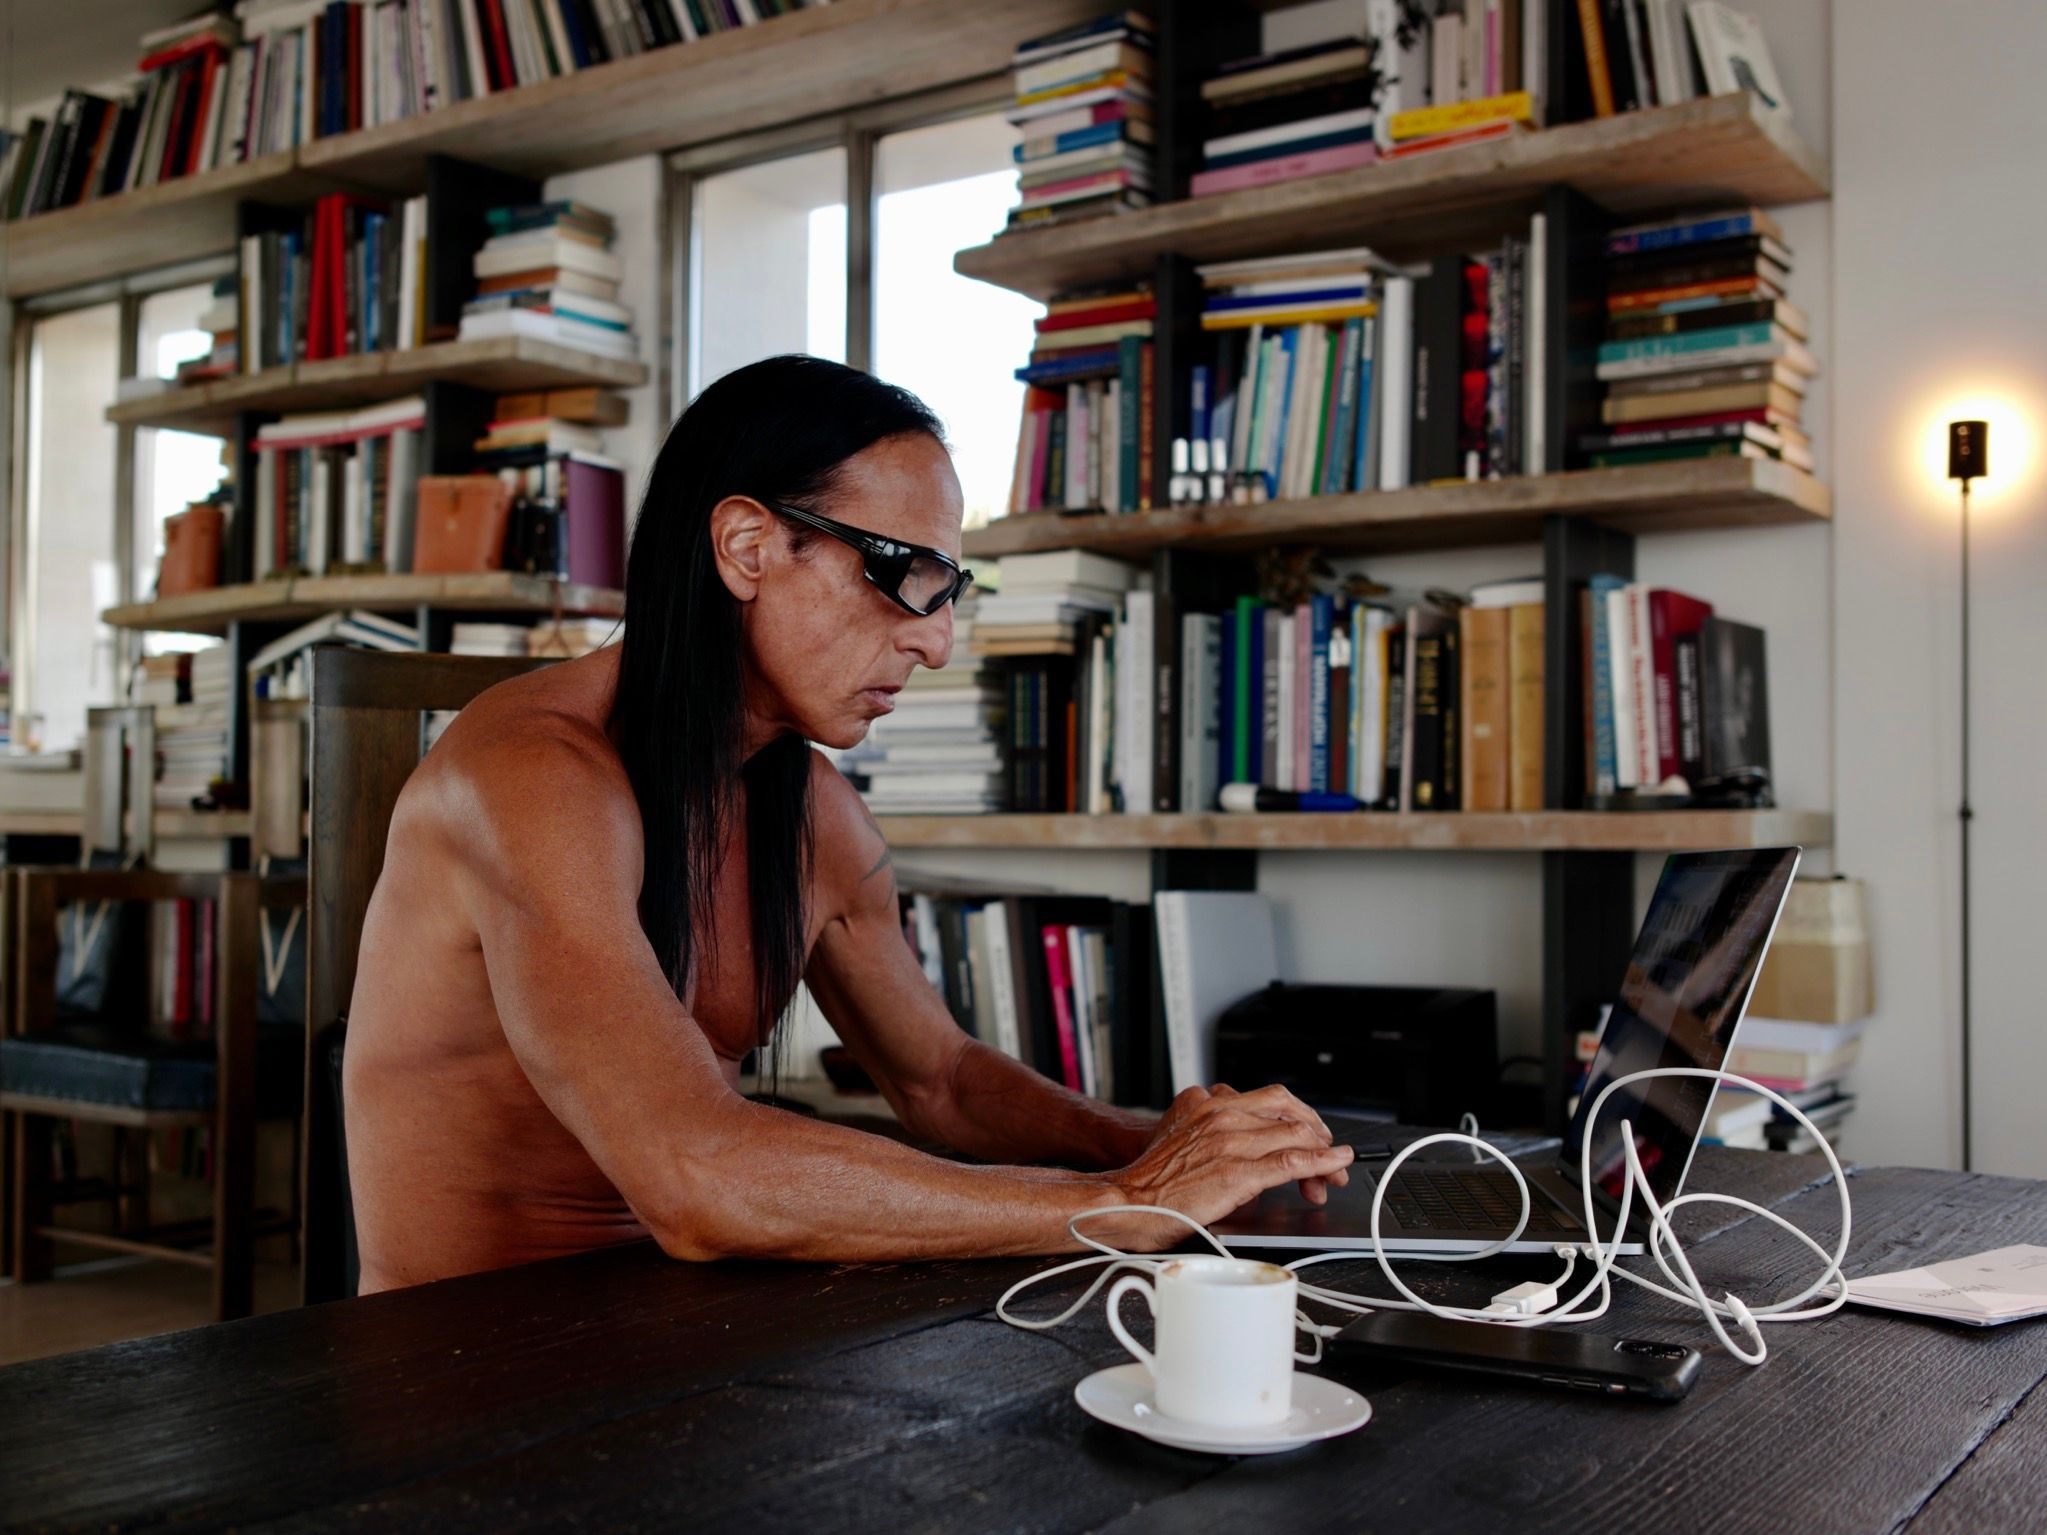

In [34]:
from IPython.display import Image
Image(filename = '/Users/omaraldakheel/Desktop/mobileNet-samples/1.png', width=300, height=200)


In [35]:
preprocessed_image = prepare_image('1.png')
predictions = mobile.predict(preprocessed_image)
results = imagenet_utils.decode_predictions(predictions)
results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n02871525', 'bookshop', np.float32(0.58035624)),
  ('n03661043', 'library', np.float32(0.33118892)),
  ('n02870880', 'bookcase', np.float32(0.087038614)),
  ('n06596364', 'comic_book', np.float32(0.0006216538)),
  ('n03255030', 'dumbbell', np.float32(0.00011703097))]]

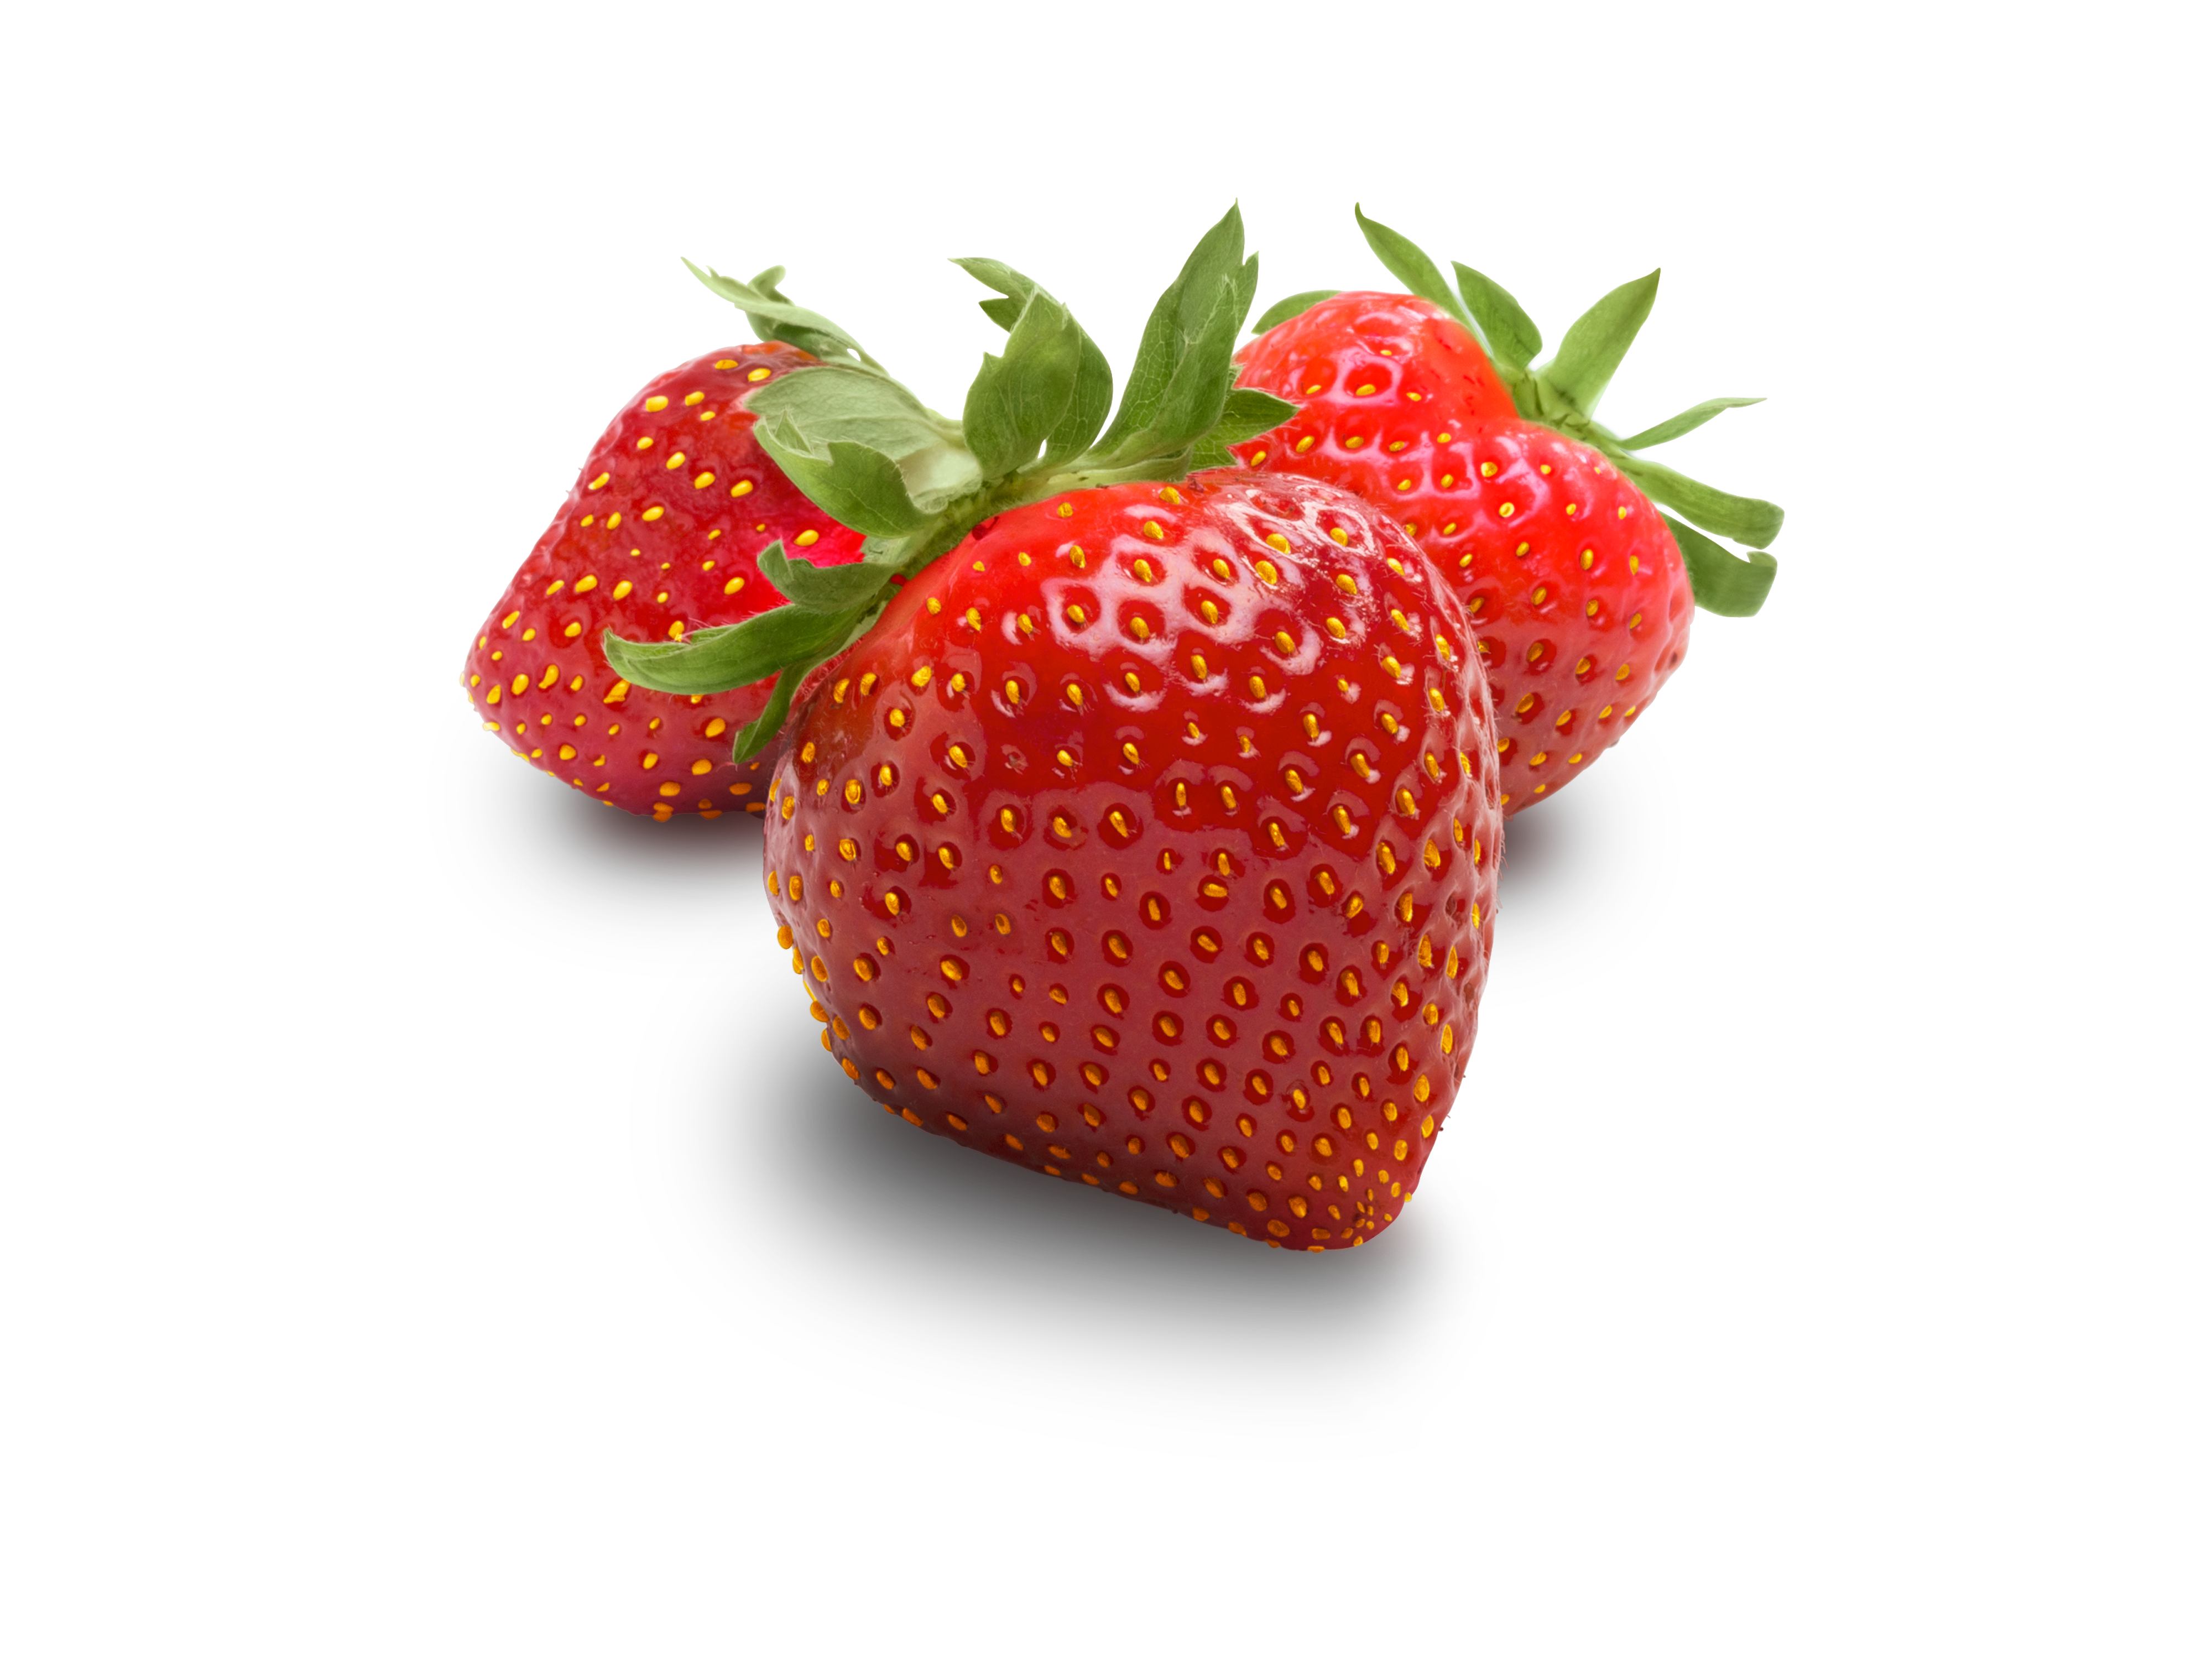

In [49]:
Image(filename = '/Users/omaraldakheel/Desktop/mobileNet-samples/5.png', width=300, height=200)

In [48]:
preprocessed_image = prepare_image('5.png')
predictions = mobile.predict(preprocessed_image)
results = imagenet_utils.decode_predictions(predictions)
results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


[[('n07745940', 'strawberry', np.float32(0.9413327)),
  ('n07747607', 'orange', np.float32(0.014420964)),
  ('n04476259', 'tray', np.float32(0.0060041896)),
  ('n07749582', 'lemon', np.float32(0.005198805)),
  ('n07754684', 'jackfruit', np.float32(0.004023176))]]

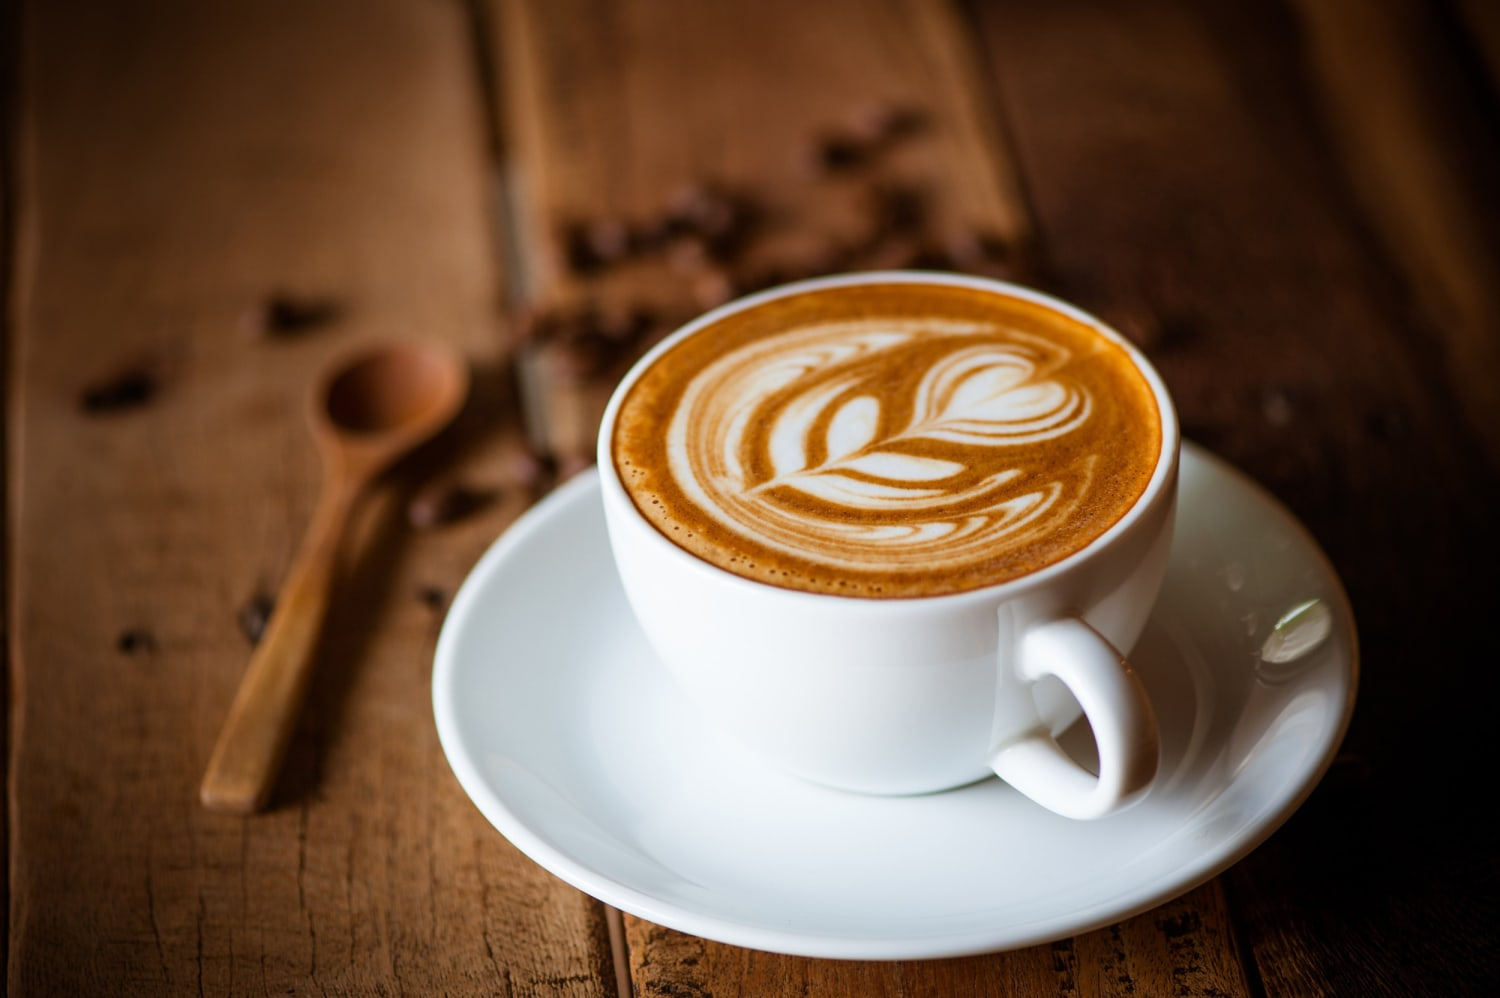

In [42]:
Image(filename = '/Users/omaraldakheel/Desktop/mobileNet-samples/3.png', width=300, height=200)

In [43]:
preprocessed_image = prepare_image('3.png')
predictions = mobile.predict(preprocessed_image)
results = imagenet_utils.decode_predictions(predictions)
results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


[[('n07920052', 'espresso', np.float32(0.92402005)),
  ('n07930864', 'cup', np.float32(0.050970066)),
  ('n03063599', 'coffee_mug', np.float32(0.020290567)),
  ('n03733805', 'measuring_cup', np.float32(0.0010955165)),
  ('n03063689', 'coffeepot', np.float32(0.001015689))]]

# *PROCESSING NOVEL DATA ON MOBILENET*

In [51]:
# organize data intro train, valid, test dirs
os.chdir('/Users/omaraldakheel/Sign-Language-Digits-Dataset')
if os.path.isdir('train/0/') is False:
    os.mkdir('train')
    os.mkdir('valid')
    os.mkdir('test')

    for i in range(0, 10):
        shutil.move(f'{i}', 'train')
        os.mkdir(f'valid/{i}')
        os.mkdir(f'test/{i}')

        valid_samples = random.sample(os.listdir(f'train/{i}'), 30)
        for j in valid_samples:
            shutil.move(f'train/{i}/{j}', f'valid/{i})')

        test_samples = random.sample(os.listdir(f'valid/{i}'), 5)
        for k in test_samples:
            shutil.move(f'train/{i}/{k}', f'test/{i}')
os.chdir('../..')